In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from train import train_model

In [3]:
df = pd.read_csv("../data/processed/features.csv")

## Data Exploration

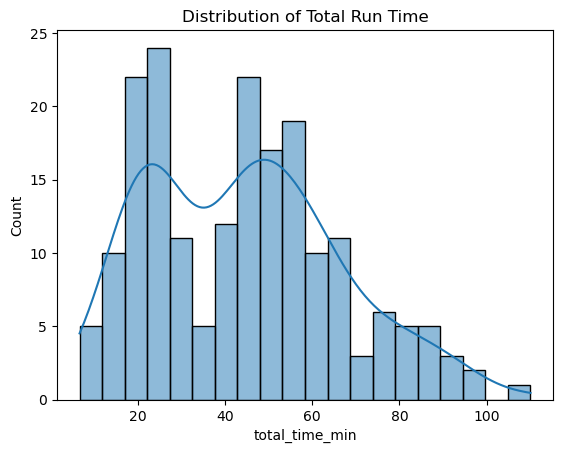

In [7]:
sns.histplot(df['total_time_min'], bins=20, kde=True)
plt.title("Distribution of Total Run Time")
plt.show()

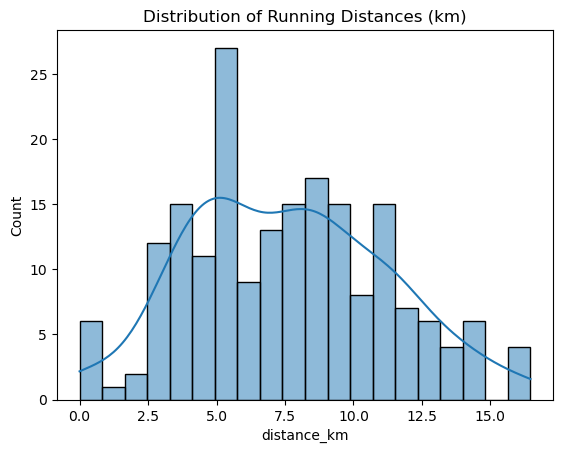

In [3]:
sns.histplot(df['distance_km'], bins=20, kde=True)
plt.title("Distribution of Running Distances (km)")
plt.show()

In [8]:
features = [
    "distance_km",
    "avg_hr",
    "avg_cadence",
    "elevation_per_km",
    "weekly_km",
    "rolling_pace",
    "hr_percent_max",
    "effort_pace"
]
corr = df[features + ["total_time_min"]].corr()
print(corr["total_time_min"].sort_values(ascending=False))

total_time_min      1.000000
distance_km         0.771702
weekly_km           0.247428
effort_pace         0.172621
rolling_pace        0.001604
avg_cadence        -0.065106
hr_percent_max     -0.090208
avg_hr             -0.120658
elevation_per_km   -0.179739
Name: total_time_min, dtype: float64


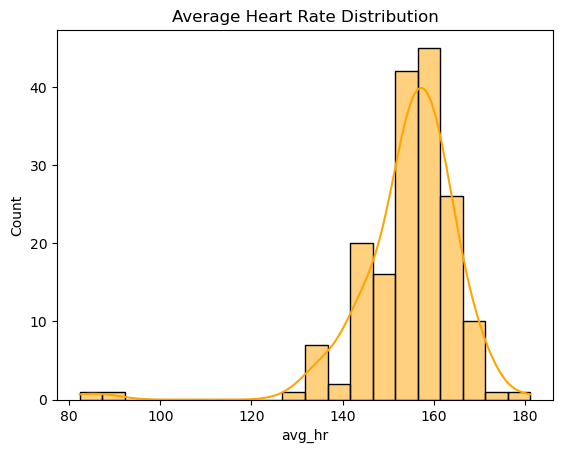

In [4]:
sns.histplot(df['avg_hr'], bins=20, kde=True, color='orange')
plt.title("Average Heart Rate Distribution")
plt.show()

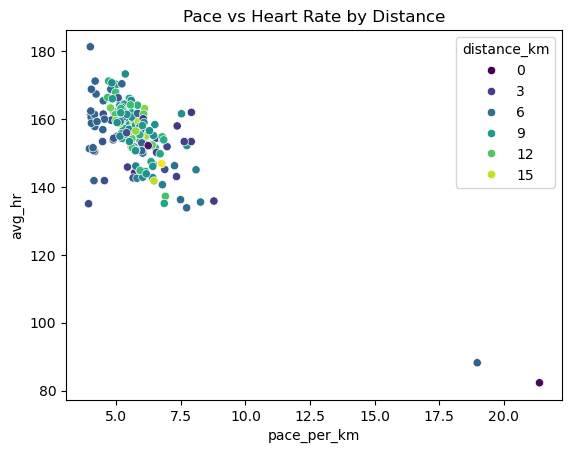

In [5]:
sns.scatterplot(x='pace_per_km', y='avg_hr', data=df, hue='distance_km', palette='viridis')
plt.title("Pace vs Heart Rate by Distance")
plt.show()


## Model Prediction

In [11]:
results = train_model()

model = results["model"]
y_val = results["y_val"]
preds = results["preds"]
features = results["features"]

def plot_model_comparison(results_df):
    plt.figure()
    plt.bar(results_df["Model"], results_df["RMSE"])
    plt.title("Model Comparison (RMSE)")
    plt.xlabel("Model")
    plt.ylabel("RMSE")
    plt.xticks(rotation=30)
    plt.show()
plot_model_comparison(results["results"])


KeyError: 'results'

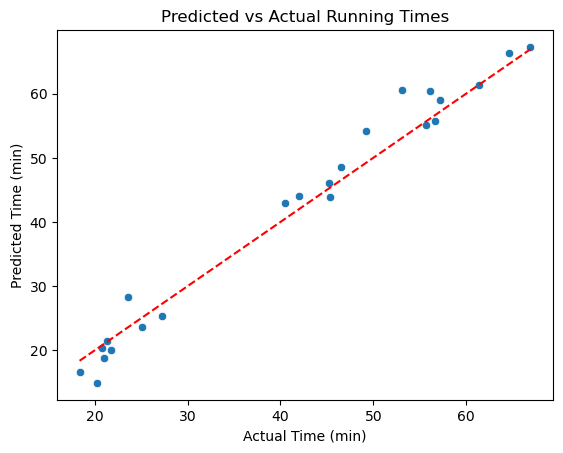

In [7]:
sns.scatterplot(x=y_val, y=preds)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         linestyle="--",c="red")
plt.xlabel("Actual Time (min)")
plt.ylabel("Predicted Time (min)")
plt.title("Predicted vs Actual Running Times")
plt.show()


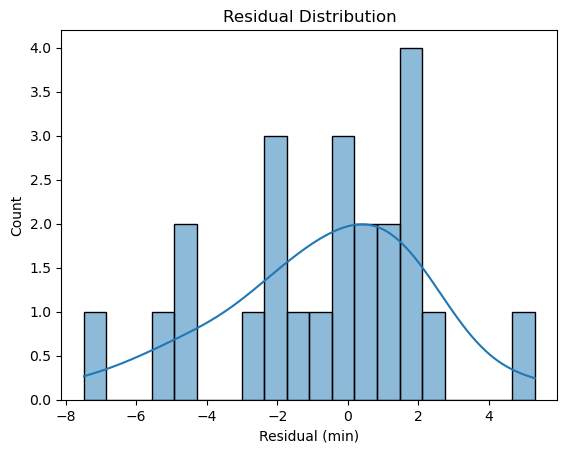

In [8]:
residuals = y_val - preds
sns.histplot(residuals, bins=20, kde=True)
plt.xlabel("Residual (min)")
plt.title("Residual Distribution")
plt.show()


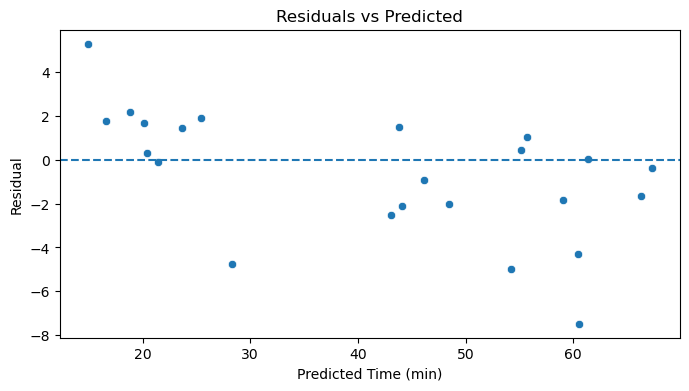

In [9]:
plt.figure(figsize=(8,4))
sns.scatterplot(x=preds, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Time (min)")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()
